# Medical Dialogue Classification with Bi-LSTM
## Task: Classify medical sections from patient-doctor dialogues


Given that in the previous delivery we did not apply Bi-LSTM and fine-tuned a model instead, we will complete the process as we said we would.
Here, you can find the process followed to build a custom architecture based on LSTM in order to build a Bi-LSTM for a classification task.

Famous models as ELMo (Embeddings from Language Models) are based on bidirectional LSTM architectures, but the datasets they are trained with and the parameters/weights they train are much larger that the one we have here, but this structure is the base for that famous technology!!

Some cuda drivers gave us problems, therefore, this training is run in CPU, that functionality is controlled by a boolean value

In [3]:
using_gpu = False

In [4]:
# JIT compilation gave us problems on GPU, you may disable it if needed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, 
    Dropout, GlobalMaxPooling1D, Concatenate, 
    BatchNormalization, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

if not using_gpu:
    tf.config.set_visible_devices([], 'GPU')

# set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


DATASET INFORMATION
Training set size: 1201
Validation set size: 100

Columns: ['ID', 'section_header', 'section_text', 'dialogue']

SAMPLE TRAINING DATA
   ID section_header                                       section_text  \
0   0          GENHX  The patient is a 76-year-old white female who ...   
1   1          GENHX  The patient is a 25-year-old right-handed Cauc...   
2   2          GENHX  This is a 22-year-old female, who presented to...   

                                            dialogue  
0  Doctor: What brings you back into the clinic t...  
1  Doctor: How're you feeling today?  \r\nPatient...  
2  Doctor: Hello, miss. What is the reason for yo...  

AVAILABLE SECTIONS (CLASSES)
section_header
FAM/SOCHX        351
GENHX            282
PASTMEDICALHX    118
CC                77
PASTSURGICAL      63
ALLERGY           60
ROS               60
MEDICATIONS       54
ASSESSMENT        34
EXAM              23
DIAGNOSIS         19
DISPOSITION       15
PLAN              11
EDCOUR

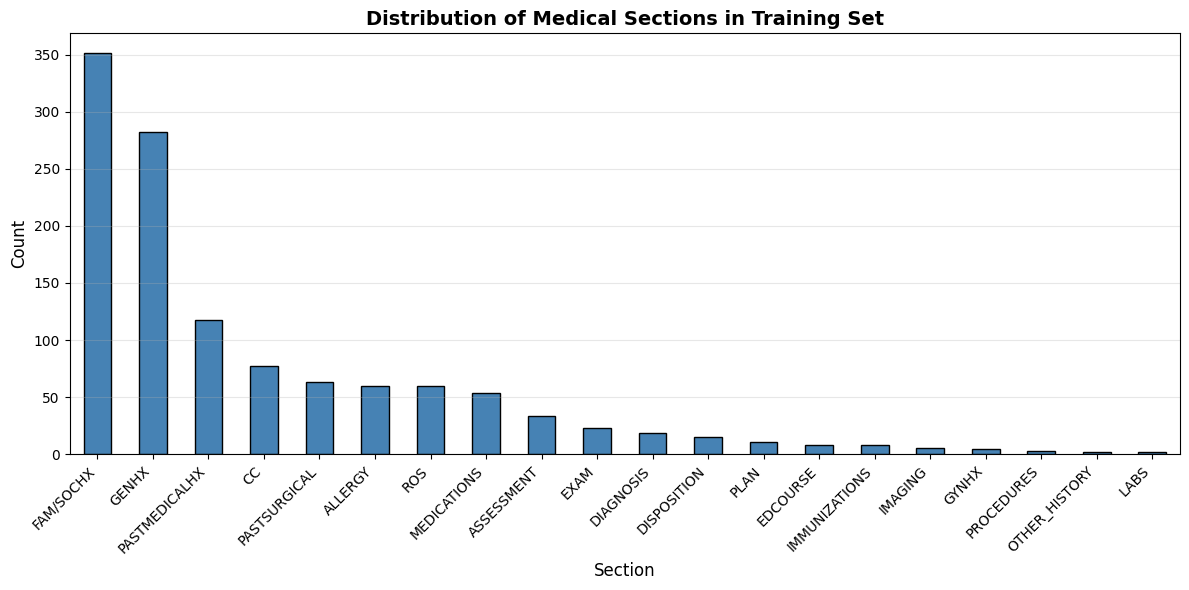

In [5]:
# DATA LOADING

train_df = pd.read_csv("../../dataset/MTS-Dialog-TrainingSet.csv")
val_df = pd.read_csv("../../dataset/MTS-Dialog-ValidationSet.csv")

print(f"\n{'='*70}")
print("DATASET INFORMATION")
print('='*70)
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"\nColumns: {train_df.columns.tolist()}")

# sample data from training set analysis
print("\n" + "="*70)
print("SAMPLE TRAINING DATA")
print("="*70)
print(train_df.head(3))

# check for the classification target
print("\n" + "="*70)
print("AVAILABLE SECTIONS (CLASSES)")
print("="*70)
section_counts = train_df['section_header'].value_counts()
print(section_counts)

# class distribution visualization
plt.figure(figsize=(12, 6))
section_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Medical Sections in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Section', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# DATA PREPROCESSING

print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# Combine train and validation for consistent preprocessing
all_data = pd.concat([train_df, val_df], axis=0)

# Handle missing values
train_df['dialogue'] = train_df['dialogue'].fillna('').astype(str)
train_df['section_header'] = train_df['section_header'].fillna('UNKNOWN').astype(str)

val_df['dialogue'] = val_df['dialogue'].fillna('').astype(str)
val_df['section_header'] = val_df['section_header'].fillna('UNKNOWN').astype(str)

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(all_data['section_header'])

y_train_encoded = label_encoder.transform(train_df['section_header'])
y_val_encoded = label_encoder.transform(val_df['section_header'])

num_classes = len(label_encoder.classes_)
print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {list(label_encoder.classes_)}")

# Tokenization parameters
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 300
EMBEDDING_DIM = 128

print(f"\nTokenization Parameters:")
print(f"  - Max Vocabulary Size: {MAX_VOCAB_SIZE}")
print(f"  - Max Sequence Length: {MAX_SEQUENCE_LENGTH}")
print(f"  - Embedding Dimension: {EMBEDDING_DIM}")

# Tokenize the dialogues
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<UNK>")
tokenizer.fit_on_texts(train_df['dialogue'])

X_train_seq = tokenizer.texts_to_sequences(train_df['dialogue'])
X_val_seq = tokenizer.texts_to_sequences(val_df['dialogue'])

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nTraining data shape: {X_train_pad.shape}")
print(f"Validation data shape: {X_val_pad.shape}")

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"Actual vocabulary size: {vocab_size}")




DATA PREPROCESSING

Number of classes: 20
Classes: ['ALLERGY', 'ASSESSMENT', 'CC', 'DIAGNOSIS', 'DISPOSITION', 'EDCOURSE', 'EXAM', 'FAM/SOCHX', 'GENHX', 'GYNHX', 'IMAGING', 'IMMUNIZATIONS', 'LABS', 'MEDICATIONS', 'OTHER_HISTORY', 'PASTMEDICALHX', 'PASTSURGICAL', 'PLAN', 'PROCEDURES', 'ROS']

Tokenization Parameters:
  - Max Vocabulary Size: 10000
  - Max Sequence Length: 300
  - Embedding Dimension: 128

Training data shape: (1201, 300)
Validation data shape: (100, 300)
Actual vocabulary size: 5356


Our architecture of selection is a bidirectional LongShortTermMemory model. The reason is the core of LSTM models, which are characterized by being able to remember the begining of the text and not miss relevant information. We used this type of models in the past when training a monetary currency price anomaly detector!! Developed by the same team and publicly available [here for your convenience :)](https://github.com/josuviteri/time-series-anomaly-detection)
    
Lets get into the architecture:

Custom Bi-LSTM architecture, focused in dialog understanding (for our classification task)
    
    Architecture:
    1. Embedding layer
    2. Spatial Dropout (for regularization)
    3. First Bidirectional LSTM layer
    4. Batch Normalization
    5. Second Bidirectional LSTM layer
    6. Global Max Pooling
    7. Dense layers (Dropout)
    8. Output layer (Softmax)


Now, we will translate some of the concepts so real people can understand:

The embedding layer, acts as a dictionary for the model, giving the model undertanding and the relation between words.

The spatial dropout acts as a filter, helping the model not to rely on specific words and overfitting with them. As people that don't seem to be able to talk without saying "EN PLAN DE" and "TIPO".

The Bidirectional LSTM is the core of our model, it reads the model in both directions.

Batch normalization is used to standarize the data that goes throught the network.

The secont Bi-LSTM reads the text again, once the first pass understands the context, this one gives us a deeper understanding of the reading.

The dense layer is used to take a decision in respect of the weights and a dropout is added not to overfit, as explained before at spatial dropout.

The final decision is taken at the output layer, which contains a "softmax" function, the list of decisions available in different probabilities. Those probabilities are the confidence our model has on an specific answer.


In [7]:
# CUSTOM BI-LSTM ARCHITECTURE

def create_bilstm_classifier(vocab_size, embedding_dim, max_length, num_classes, 
                            lstm_units=128, dropout_rate=0.4):
    
    print("\n" + "="*70)
    print("BUILDING CUSTOM BI-LSTM ARCHITECTURE")
    print("="*70)
    
    inputs = Input(shape=(max_length,), name='dialogue_input')
    
    # Embedding layer
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length,
        trainable=True,
        mask_zero=True,
        name='embedding'
    )(inputs)
    
    # Spatial dropout for embedding regularization
    x = SpatialDropout1D(0.2, name='spatial_dropout')(x)
    
    # First Bi-LSTM layer (return sequences for stacking)
    x = Bidirectional(
        LSTM(lstm_units, return_sequences=True, dropout=dropout_rate, recurrent_dropout=0.2),
        name='bilstm_1'
    )(x)
    
    # Batch normalization
    x = BatchNormalization(name='batch_norm_1')(x)
    
    # second Bi-LSTM layer
    x = Bidirectional(
        LSTM(lstm_units // 2, return_sequences=True, dropout=dropout_rate, recurrent_dropout=0.2),
        name='bilstm_2'
    )(x)
    
    # Global Max Pooling to extract most important features
    x = GlobalMaxPooling1D(name='global_max_pooling')(x)
    
    # Dense layers with dropout
    x = Dense(128, activation='relu', name='dense_1')(x)
    x = BatchNormalization(name='batch_norm_2')(x)
    x = Dropout(dropout_rate, name='dropout_1')(x)
    
    x = Dense(64, activation='relu', name='dense_2')(x)
    x = Dropout(dropout_rate, name='dropout_2')(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax', name='output')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='BiLSTM_Classifier')
    
    return model

# Create the model
model = create_bilstm_classifier(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    lstm_units=128,
    dropout_rate=0.4
)

# Display model architecture
print("\n" + "="*70)
print("MODEL ARCHITECTURE SUMMARY")
print("="*70)
model.summary()

# Count parameters
trainable_params = sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = sum([np.prod(v.shape) for v in model.non_trainable_weights])
print(f"\nTotal trainable parameters: {trainable_params:,}")
print(f"Total non-trainable parameters: {non_trainable_params:,}")

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled successfully")



BUILDING CUSTOM BI-LSTM ARCHITECTURE

MODEL ARCHITECTURE SUMMARY


/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "BiLSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dialogue_input      │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │    685,568 │ dialogue_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 300, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 300)       │          0 │ dialogue_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 300, 256)  │    263,168 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_1        │ (None, 300, 256)  │      1,024 │ bilstm_1[0][0],   │
│ (BatchNormalizatio… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 300, 128)  │    164,352 │ batch_norm_1[0][… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling  │ (None, 128)       │          0 │ bilstm_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_2        │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_norm_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 20)        │      1,300 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,140,692 (4.35 MB)

 Trainable params: 1,139,924 (4.35 MB)

 Non-trainable params: 768 (3.00 KB)


Total trainable parameters: 1,139,924
Total non-trainable parameters: 768

Model compiled successfully


The application of callbacks is used to keep track of the training and be able to recover the training if anything fails!

In [8]:

# TRAINING WITH CALLBACKS

print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)

# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        'best_bilstm_classifier.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )
]

print("Callbacks configured:")
print("  - Early Stopping (patience=5)")
print("  - Learning Rate Reduction (patience=3)")
print("  - Model Checkpoint (save best model)")

# Training parameters
BATCH_SIZE = 16
EPOCHS = 50

print(f"\nTraining Parameters:")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Max Epochs: {EPOCHS}")
print(f"  - Optimizer: Adam (lr=0.001)")
print(f"  - Loss: Sparse Categorical Crossentropy")

# Train the model
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

history = model.fit(
    X_train_pad, y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")



TRAINING CONFIGURATION
Callbacks configured:
  - Early Stopping (patience=5)
  - Learning Rate Reduction (patience=3)
  - Model Checkpoint (save best model)

Training Parameters:
  - Batch Size: 16
  - Max Epochs: 50
  - Optimizer: Adam (lr=0.001)
  - Loss: Sparse Categorical Crossentropy

STARTING TRAINING
Epoch 1/50


2026-01-06 10:38:21.022751: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a4cf003e2a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-01-06 10:38:21.022790: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-01-06 10:38:21.380833: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767692307.777900   10857 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1791 - loss: 2.9399
Epoch 1: val_accuracy improved from None to 0.22000, saving model to best_bilstm_classifier.keras

Epoch 1: finished saving model to best_bilstm_classifier.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.2723 - loss: 2.6297 - val_accuracy: 0.2200 - val_loss: 2.8272 - learning_rate: 0.0010
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4114 - loss: 2.0870
Epoch 2: val_accuracy did not improve from 0.22000
76/76 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.4380 - loss: 2.0129 - val_accuracy: 0.2200 - val_loss: 2.7924 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.5256 - loss: 1.6494
Epoch 3: val_accuracy improved from 0.22000 to 0.29000, saving model to best_bilstm_classifier.keras

Epoch 3: finished saving model to best_bilstm_classifier.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.5362 - loss: 1.6849 - val_accuracy: 0.2900 - val_


MODEL EVALUATION


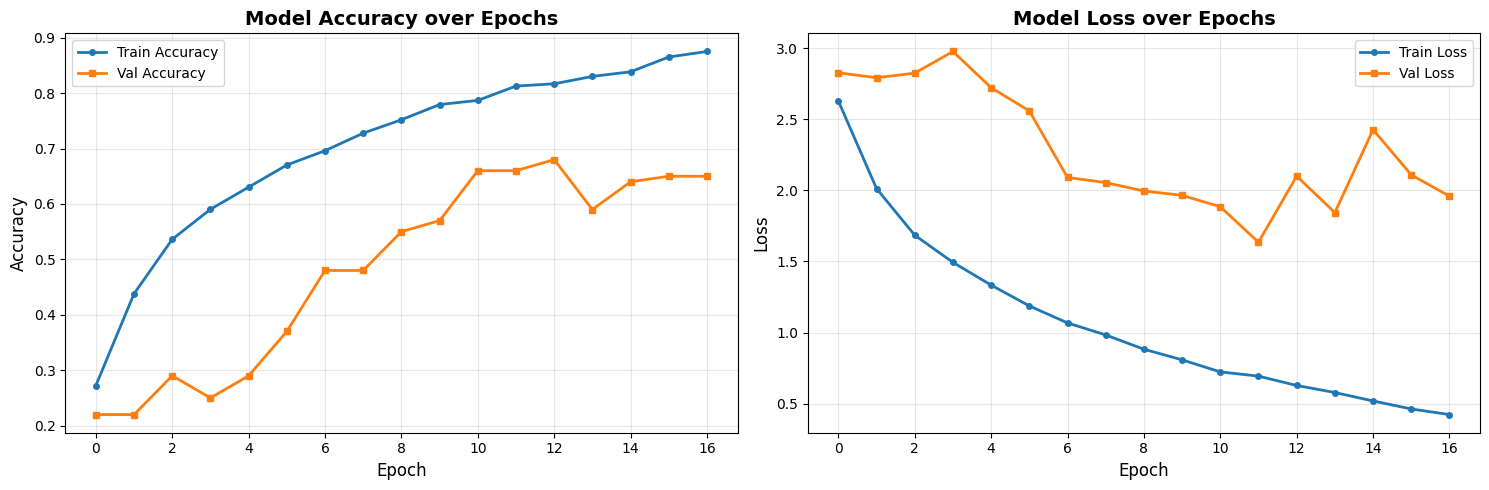


Generating predictions on validation set...

FINAL RESULTS
Validation Accuracy: 0.6600 (66.00%)
Weighted F1-Score:   0.6119
Macro F1-Score:      0.2701

DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

      ALLERGY     0.3333    0.2500    0.2857         4
   ASSESSMENT     0.0000    0.0000    0.0000         4
           CC     0.6667    0.5000    0.5714         4
    DIAGNOSIS     0.0000    0.0000    0.0000         1
  DISPOSITION     0.0000    0.0000    0.0000         2
     EDCOURSE     0.0000    0.0000    0.0000         3
         EXAM     0.0000    0.0000    0.0000         1
    FAM/SOCHX     0.7857    1.0000    0.8800        22
        GENHX     0.8000    0.8000    0.8000        20
        GYNHX     0.0000    0.0000    0.0000         1
      IMAGING     0.0000    0.0000    0.0000         1
IMMUNIZATIONS     0.0000    0.0000    0.0000         1
         LABS     0.0000    0.0000    0.0000         1
  MEDICATIONS     0.4667    1.0000    0.6364

/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [9]:
# EVALUATION AND VISUALIZATION

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o', markersize=4)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s', markersize=4)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
axes[1].set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Get predictions
print("\nGenerating predictions on validation set...")
y_pred_probs = model.predict(X_val_pad, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_val_encoded, y_pred)
f1_weighted = f1_score(y_val_encoded, y_pred, average='weighted')
f1_macro = f1_score(y_val_encoded, y_pred, average='macro')

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print(f"Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Weighted F1-Score:   {f1_weighted:.4f}")
print(f"Macro F1-Score:      {f1_macro:.4f}")

# Classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(
    y_val_encoded, 
    y_pred, 
    target_names=label_encoder.classes_,
    digits=4
))

As you can see, the early stopping triggered at the 6th epoch, as the model failed to properly learn and minimize the loss.
But in our case, we think that the eraly stopping may have kept the model from learning, therefore, we will remove it for experimentation.

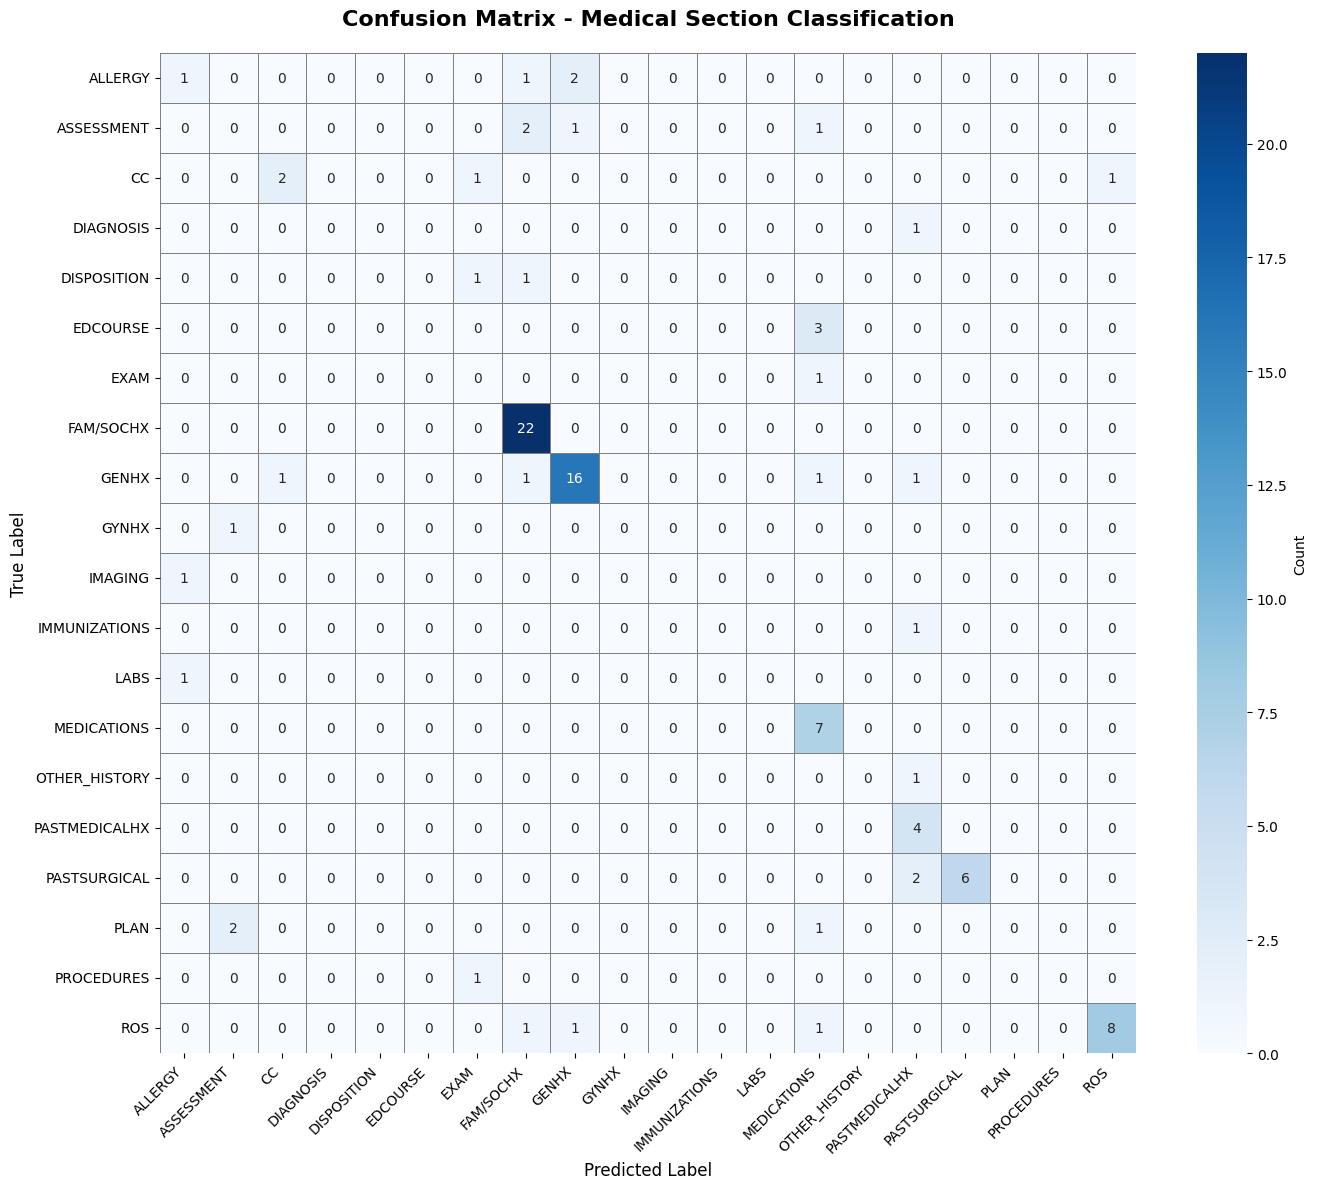


PER-CLASS ACCURACY
ALLERGY                       : 0.2500 (25.00%)
ASSESSMENT                    : 0.0000 (0.00%)
CC                            : 0.5000 (50.00%)
DIAGNOSIS                     : 0.0000 (0.00%)
DISPOSITION                   : 0.0000 (0.00%)
EDCOURSE                      : 0.0000 (0.00%)
EXAM                          : 0.0000 (0.00%)
FAM/SOCHX                     : 1.0000 (100.00%)
GENHX                         : 0.8000 (80.00%)
GYNHX                         : 0.0000 (0.00%)
IMAGING                       : 0.0000 (0.00%)
IMMUNIZATIONS                 : 0.0000 (0.00%)
LABS                          : 0.0000 (0.00%)
MEDICATIONS                   : 1.0000 (100.00%)
OTHER_HISTORY                 : 0.0000 (0.00%)
PASTMEDICALHX                 : 1.0000 (100.00%)
PASTSURGICAL                  : 0.7500 (75.00%)
PLAN                          : 0.0000 (0.00%)
PROCEDURES                    : 0.0000 (0.00%)
ROS                           : 0.7273 (72.73%)


In [11]:

# Confusion matrix
cm = confusion_matrix(y_val_encoded, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Confusion Matrix - Medical Section Classification', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n" + "="*70)
print("PER-CLASS ACCURACY")
print("="*70)
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name:30s}: {class_accuracy[i]:.4f} ({class_accuracy[i]*100:.2f}%)")

In [ ]:
# Class prediction function for inference test on validation set

def predict_section(dialogue_text, model, tokenizer, label_encoder, max_length):

    # Preprocess
    seq = tokenizer.texts_to_sequences([dialogue_text])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')
    
    # Predict
    pred_probs = model.predict(padded, verbose=0)
    pred_class_idx = np.argmax(pred_probs, axis=1)[0]
    pred_class = label_encoder.inverse_transform([pred_class_idx])[0]
    confidence = pred_probs[0][pred_class_idx]
    
    return pred_class, confidence, pred_probs[0]

In [13]:
print("\n" + "="*70)
print("EXAMPLE PREDICTIONS")
print("="*70)


# Inference test on first 5 validation set examples
num_examples = min(5, len(val_df))
for i in range(num_examples):
    dialogue = val_df.iloc[i]['dialogue']
    true_section = val_df.iloc[i]['section_header']
    
    pred_section, confidence, all_probs = predict_section(
        dialogue, model, tokenizer, label_encoder, MAX_SEQUENCE_LENGTH
    )
    
    print(f"\n{'─'*70}")
    print(f"Example {i+1}")
    print(f"{'─'*70}")
    print(f"Dialogue (first 200 chars):\n{dialogue[:200]}...")
    print(f"\nTrue Section:      {true_section}")
    print(f"Predicted Section: {pred_section}")
    print(f"Confidence:        {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"Correct:           {'✓ YES' if pred_section == true_section else '✗ NO'}")
    
    # Show top 3 predictions
    top_3_idx = np.argsort(all_probs)[-3:][::-1]
    print(f"\nTop 3 Predictions:")
    for rank, idx in enumerate(top_3_idx, 1):
        class_name = label_encoder.inverse_transform([idx])[0]
        prob = all_probs[idx]
        print(f"  {rank}. {class_name:30s} ({prob:.4f})")


EXAMPLE PREDICTIONS

──────────────────────────────────────────────────────────────────────
Example 1
──────────────────────────────────────────────────────────────────────
Dialogue (first 200 chars):
Doctor: When did your pain begin? 
Patient: I've had low back pain for about eight years now.
Doctor: Is there any injury? 
 Patient: Yeah, it started when I fell in an A B C store.
Doctor: How old ar...

True Section:      GENHX
Predicted Section: GENHX
Confidence:        0.9994 (99.94%)
Correct:           ✓ YES

Top 3 Predictions:
  1. GENHX                          (0.9994)
  2. FAM/SOCHX                      (0.0002)
  3. ROS                            (0.0001)

──────────────────────────────────────────────────────────────────────
Example 2
──────────────────────────────────────────────────────────────────────
Dialogue (first 200 chars):
Doctor: Hey, bud. What brings you in today? 
Patient: A rash on my upper arms and torso. 
Doctor: When did it start? 
Patient: Bout a day or two ag

With these metrics, we can see that even if the model achieved to get progress throught training, minimizing the validation loss, and maximizing the accuracy, the model does not achieve to perform correctly. Having great confidence to take an incorrect decision is not the way to go. We consider that the reason for the result may have been the class imbalance, as some classes appear more than others, and training with our training sample may have made us go this way. Therefore, fine tuning a model trained with more data in a more generalized approach using our clinical context may be the way to go. We will see with the fine tuning of distilBERT (uncased). 